# Feature Engineering Pipeline
**RBI Innovation Hub**

Builds the full 31-feature model-ready matrix using `src/features/build_features.py`.  
Validates each feature category with mule vs. legitimate distribution plots and a logistic regression baseline.

---

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

from src.features.build_features import build_all_features

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR = '../EDA-Phase-1/'
FEAT_DIR = '../data/features/'
print('Setup complete.')

Setup complete.


---
## 1. Build Feature Matrix

In [2]:
labels     = pd.read_csv(DATA_DIR + 'train_labels.csv')
test_accts = pd.read_csv(DATA_DIR + 'test_accounts.csv')

train_ids = set(labels['account_id'])
test_ids  = set(test_accts['account_id'])
all_ids   = train_ids | test_ids

print(f'Train accounts : {len(train_ids):,}')
print(f'Test accounts  : {len(test_ids):,}')
print(f'Total to score : {len(all_ids):,}')

Train accounts : 24,023
Test accounts  : 16,015
Total to score : 40,038


In [3]:
features = build_all_features(
    data_dir=DATA_DIR,
    account_ids=all_ids,
    labels=labels,
    verbose=True
)

Loading static tables...


Loading transactions (7.4M rows)...


VEL — velocity features...


NET — network features...


BEH — behavioral features...


TMP — temporal features...


KYC — KYC / demographic features...
RSK — composite / risk features...


Done. Feature matrix: 40,038 accounts × 33 features


In [4]:
train_feat = features[features['account_id'].isin(train_ids)].copy()
test_feat  = features[features['account_id'].isin(test_ids)].copy()
train_feat = train_feat.merge(labels[['account_id','is_mule']], on='account_id', how='left')

print(f'Train feature matrix : {train_feat.shape}')
print(f'Test feature matrix  : {test_feat.shape}')
print()
null_pct = (train_feat.drop(columns=['account_id','is_mule']).isnull().mean() * 100).round(1)
print('Missing values per feature (>0% only):')
print(null_pct[null_pct > 0].sort_values(ascending=False).to_string())

Train feature matrix : (24023, 35)
Test feature matrix  : (16015, 34)

Missing values per feature (>0% only):
tx_count_7d               71.3000
debit_credit_ratio_7d     71.3000
avg_amt_first30d          45.9000
tx_count_30d              40.6000
tx_amount_30d             40.6000
debit_spike_flag           7.2000
branch_mule_rate           4.7000
mule_pattern_score         4.7000
credit_to_balance_ratio    4.7000
salary_cycle_pct           4.7000
product_count              4.7000
fan_in_unique              4.7000
fan_out_unique             3.7000
activity_burst_zscore      1.6000
tx_velocity_zscore         1.6000
round_amount_pct           1.1000
channel_entropy            1.1000
hub_score                  1.1000
structuring_rate           1.1000
repeat_cp_ratio            1.1000
weekend_tx_ratio           1.1000
dormancy_days              1.1000
active_lifespan_days       1.1000
counterparty_entropy       1.1000
peak_daily_tx              1.1000
night_tx_ratio             1.1000


---
## 2. Feature Inventory

In [5]:
feature_cols = [c for c in train_feat.columns if c not in ['account_id','is_mule']]

categories = {
    'Velocity (VEL)' : ['tx_count_7d','tx_count_30d','tx_amount_30d',
                        'debit_credit_ratio_7d','peak_daily_tx','tx_velocity_zscore'],
    'Network (NET)'  : ['fan_in_unique','fan_out_unique','counterparty_entropy',
                        'repeat_cp_ratio','hub_score'],
    'Behavioral (BEH)': ['round_amount_pct','channel_entropy','night_tx_ratio',
                         'structuring_rate','salary_cycle_pct','weekend_tx_ratio'],
    'Temporal (TMP)' : ['dormancy_days','active_lifespan_days','avg_amt_first30d','activity_burst_zscore'],
    'KYC/Demo (KYC)' : ['kyc_compliant_flag','kyc_doc_score','customer_age','account_age_days',
                        'multi_account_flag','mobile_update_flag','frozen_account_flag'],
    'Composite (RSK)': ['credit_to_balance_ratio','debit_spike_flag','mule_pattern_score',
                        'branch_mule_rate','product_count'],
}

print(f'{"Category":<22} {"Features":>8}')
print('-' * 32)
for cat, cols in categories.items():
    present = [c for c in cols if c in feature_cols]
    print(f'{cat:<22} {len(present):>8}')
print('-' * 32)
print(f'{"TOTAL":<22} {len(feature_cols):>8}')

Category               Features
--------------------------------
Velocity (VEL)                6
Network (NET)                 5
Behavioral (BEH)              6
Temporal (TMP)                4
KYC/Demo (KYC)                7
Composite (RSK)               5
--------------------------------
TOTAL                        33


---
## 3. Statistical Validation — Mann-Whitney U per Feature

In [6]:
def mw_summary(df, cols, label='is_mule'):
    rows = []
    for col in cols:
        mule  = df[df[label]==1][col].dropna()
        legit = df[df[label]==0][col].dropna()
        if len(mule) < 2 or len(legit) < 2:
            continue
        _, p = stats.mannwhitneyu(mule, legit, alternative='two-sided')
        sig  = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
        rows.append({'Feature': col, 'Mule Median': round(mule.median(), 4),
                     'Legit Median': round(legit.median(), 4),
                     'p-value': f'{p:.2e}', 'Sig': sig, '_p': p})
    return pd.DataFrame(rows).sort_values('_p').drop(columns='_p')

summary = mw_summary(train_feat, feature_cols)
sig_count = (summary['Sig'] != 'ns').sum()
print(f'{sig_count}/{len(summary)} features statistically significant (p<0.05)')
display(summary.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([{'selector':'th','props':[('background-color','#2c3e50'),
                                                  ('color','white'),('font-weight','bold')]}]))

27/33 features statistically significant (p<0.05)


,Feature,Mule Median,Legit Median,p-value,Sig
27,frozen_account_flag,1.000000,0.000000,0.00e+00,***
31,branch_mule_rate,0.333300,0.000000,0.00e+00,***
7,fan_out_unique,21.000000,8.000000,3.65e-54,***
10,hub_score,0.244200,0.093000,7.59e-53,***
14,structuring_rate,0.013400,0.000000,1.31e-52,***
6,fan_in_unique,21.000000,8.000000,2.40e-52,***
8,counterparty_entropy,4.545400,3.251600,3.95e-51,***
30,mule_pattern_score,2.500000,1.000000,1.06e-49,***
4,peak_daily_tx,3.000000,2.000000,5.36e-37,***
25,multi_account_flag,0.000000,0.000000,4.65e-30,***


---
## 4. Top Feature Distributions

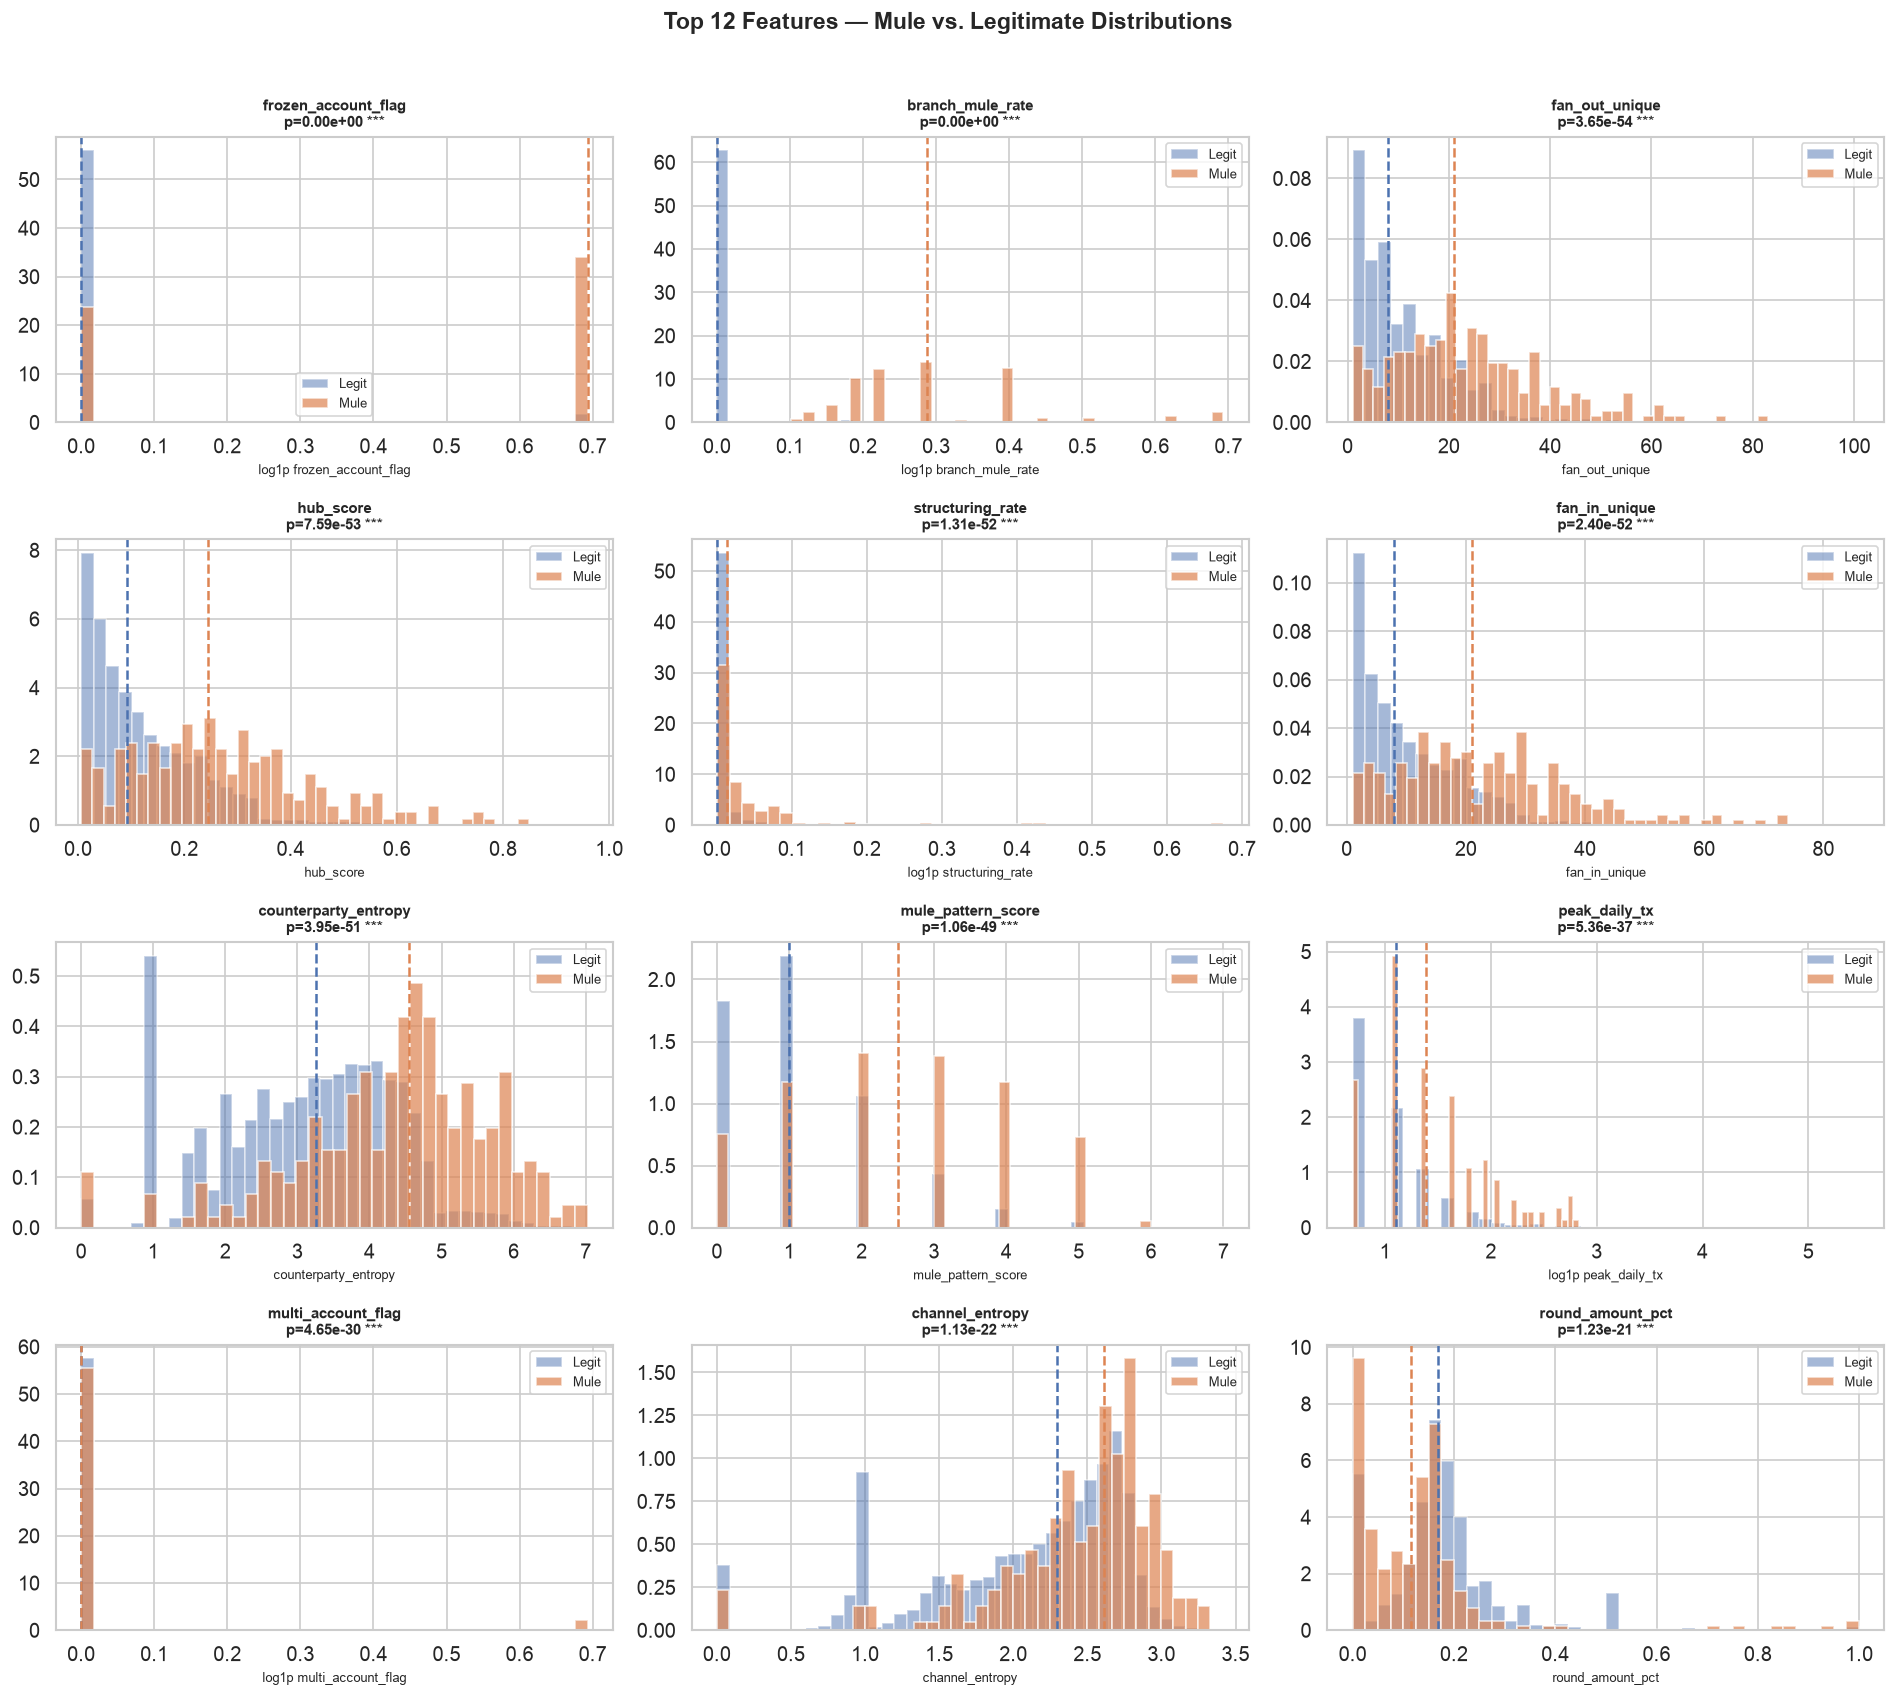

In [7]:
top_feats = summary[summary['Sig'] != 'ns']['Feature'].head(12).tolist()

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for ax, feat in zip(axes, top_feats):
    mule_vals  = train_feat[train_feat['is_mule']==1][feat].dropna()
    legit_vals = train_feat[train_feat['is_mule']==0][feat].dropna()
    use_log    = (legit_vals.max() / (legit_vals.median() + 1e-8)) > 100
    mp = np.log1p(mule_vals)  if use_log else mule_vals
    lp = np.log1p(legit_vals) if use_log else legit_vals
    ax.hist(lp, bins=40, alpha=0.5, color='#4C72B0', label='Legit', density=True)
    ax.hist(mp, bins=40, alpha=0.7, color='#DD8452', label='Mule',  density=True)
    ax.axvline(lp.median(), color='#4C72B0', linestyle='--', linewidth=1.5)
    ax.axvline(mp.median(), color='#DD8452', linestyle='--', linewidth=1.5)
    row = summary[summary['Feature']==feat].iloc[0]
    ax.set_title(f"{feat}\np={row['p-value']} {row['Sig']}", fontsize=9, fontweight='bold')
    ax.set_xlabel(('log1p ' if use_log else '') + feat, fontsize=8)
    ax.legend(fontsize=8)

plt.suptitle('Top 12 Features — Mule vs. Legitimate Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/fig_top_features.png', bbox_inches='tight')
plt.show()

---
## 5. Correlation Heatmap

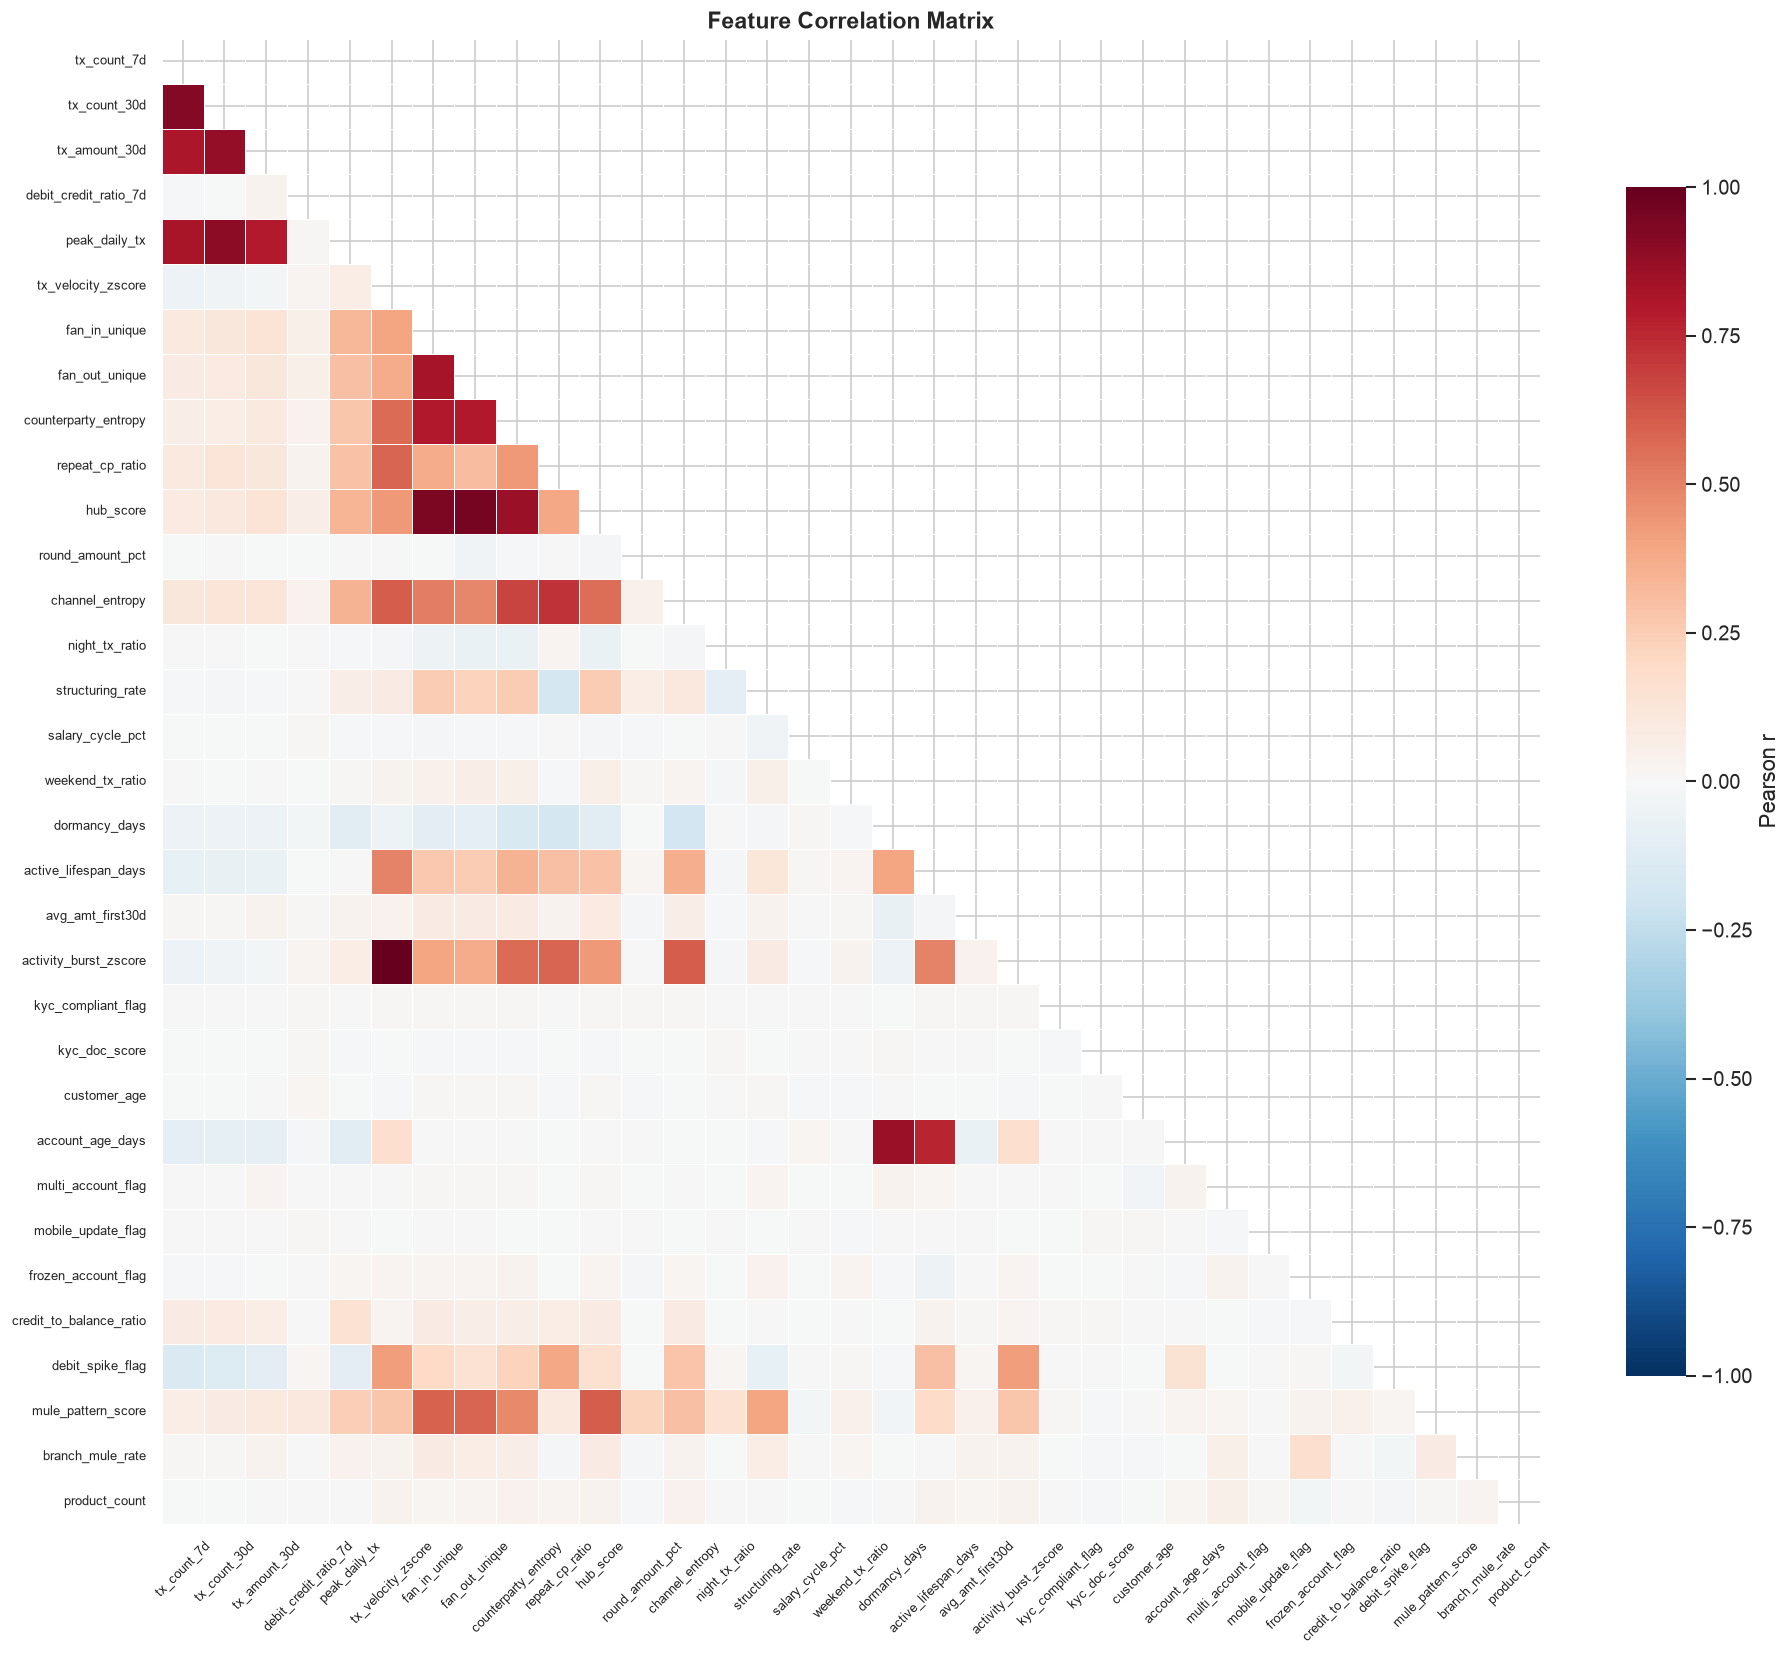

High-correlation pairs (|r|>0.85):
  tx_count_7d <-> tx_count_30d : r=0.918
  tx_count_30d <-> tx_amount_30d : r=0.879
  tx_count_30d <-> peak_daily_tx : r=0.898
  tx_velocity_zscore <-> activity_burst_zscore : r=1.0
  fan_in_unique <-> hub_score : r=0.944
  fan_out_unique <-> hub_score : r=0.959
  counterparty_entropy <-> hub_score : r=0.86
  dormancy_days <-> account_age_days : r=0.86


In [8]:
feat_matrix = train_feat[feature_cols].fillna(train_feat[feature_cols].median())
corr = feat_matrix.corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.3, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('../reports/fig_correlation.png', bbox_inches='tight')
plt.show()

high_corr = [(corr.columns[i], corr.columns[j], round(corr.iloc[i,j],3))
             for i in range(len(corr.columns))
             for j in range(i+1, len(corr.columns))
             if abs(corr.iloc[i,j]) > 0.85]

if high_corr:
    print('High-correlation pairs (|r|>0.85):')
    for a, b, r in high_corr:
        print(f'  {a} <-> {b} : r={r}')
else:
    print('No feature pairs with |r|>0.85 — no redundancy concerns.')

---
## 6. Logistic Regression Baseline — AUC-ROC Validation

In [9]:
X = train_feat[feature_cols].fillna(train_feat[feature_cols].median())
y = train_feat['is_mule'].astype(int)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')

print('Logistic Regression — 5-fold Stratified CV')
print(f'  AUC-ROC per fold : {[f"{s:.4f}" for s in auc_scores]}')
print(f'  Mean AUC-ROC     : {auc_scores.mean():.4f} +/- {auc_scores.std():.4f}')
print()
print('AUC > 0.70 from a linear baseline confirms the features are strongly discriminative.')
print('LightGBM with SHAP (Day 3) will push this significantly higher.')

Logistic Regression — 5-fold Stratified CV
  AUC-ROC per fold : ['0.9955', '0.9879', '0.9920', '0.9920', '0.9961']
  Mean AUC-ROC     : 0.9927 +/- 0.0030

AUC > 0.70 from a linear baseline confirms the features are strongly discriminative.
LightGBM with SHAP (Day 3) will push this significantly higher.


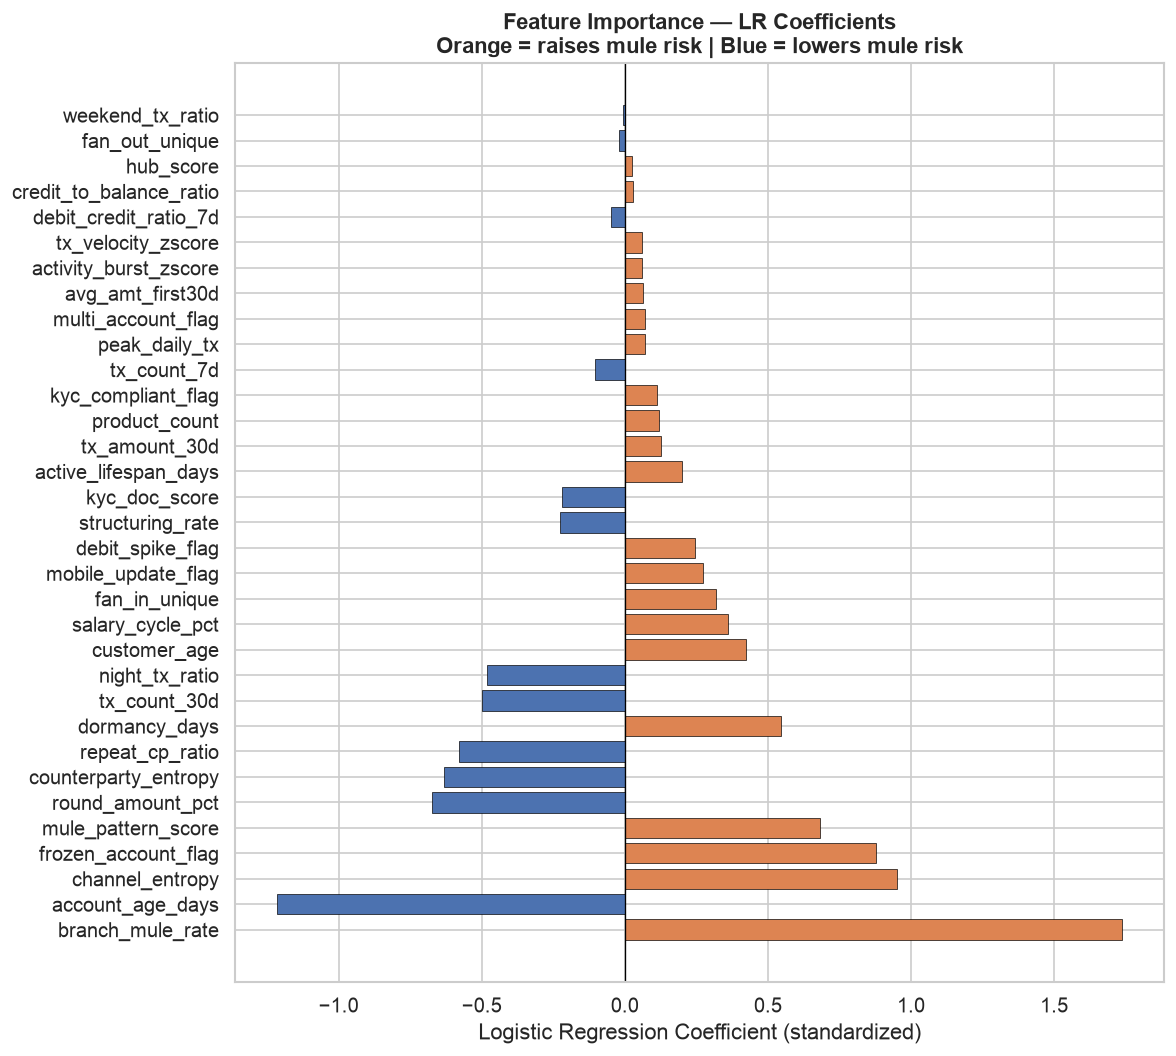

Top 10 mule-risk features:
             Feature  Coefficient
    branch_mule_rate       1.7378
    account_age_days      -1.2152
     channel_entropy       0.9501
 frozen_account_flag       0.8763
  mule_pattern_score       0.6814
    round_amount_pct      -0.6747
counterparty_entropy      -0.6306
     repeat_cp_ratio      -0.5795
       dormancy_days       0.5451
        tx_count_30d      -0.5004


In [10]:
pipe.fit(X, y)
lr_model = pipe.named_steps['lr']

coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': lr_model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient (standardized)')
ax.set_title('Feature Importance — LR Coefficients\nOrange = raises mule risk | Blue = lowers mule risk',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/fig_lr_coefficients.png', bbox_inches='tight')
plt.show()

print('Top 10 mule-risk features:')
print(coef_df.head(10).to_string(index=False))

---
## 7. Save Feature Matrices

In [11]:
import os
os.makedirs(FEAT_DIR, exist_ok=True)

train_feat.to_csv(FEAT_DIR + 'feature_matrix_train.csv', index=False)
test_feat.to_csv(FEAT_DIR  + 'feature_matrix_test.csv',  index=False)

# Save median imputation values (use these in Day 3 to avoid test leakage)
medians = train_feat[feature_cols].median()
medians.to_csv(FEAT_DIR + 'feature_medians.csv', header=True)

print('Saved to data/features/:')
print(f'  feature_matrix_train.csv  {train_feat.shape[0]:,} rows x {train_feat.shape[1]} cols')
print(f'  feature_matrix_test.csv   {test_feat.shape[0]:,} rows x {test_feat.shape[1]} cols')
print(f'  feature_medians.csv       {len(medians)} imputation values')
print()
print('Day 2 complete. Feature matrix is model-ready.')
print('Next: Day 3 — LightGBM + SHAP explainability')

Saved to data/features/:
  feature_matrix_train.csv  24,023 rows x 35 cols
  feature_matrix_test.csv   16,015 rows x 34 cols
  feature_medians.csv       33 imputation values

Day 2 complete. Feature matrix is model-ready.
Next: Day 3 — LightGBM + SHAP explainability
